<a href="https://colab.research.google.com/github/juanarayaal/ML1_ExamenAplicado_Araya_Juan/blob/main/Examen_Seoul_Bike_Sharing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Machine Learning I — Seoul Bike Sharing Demand

**Dataset:** Seoul Bike Sharing Demand  
**Fuente:** UCI Machine Learning Repository  
**URL pública:** https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand  
**Número de filas:** 8.760  
**Número de columnas:** 14  
**Variable objetivo:** Rented Bike Count  
**Tipo de tarea:** Regresión  

El objetivo del análisis es predecir la cantidad de bicicletas arrendadas por hora en el sistema público de bicicletas de Seúl a partir de variables meteorológicas, temporales y operacionales.

**Reproducibilidad:** se utiliza `random_state=42` en todos los procedimientos aleatorios cuando corresponde.


## 0. Librerías, configuración general y carpeta de figuras

In [104]:
#

from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def guardar_figura(nombre):
    plt.tight_layout()
    plt.savefig(FIG_DIR / nombre, dpi=150, bbox_inches="tight")
    plt.show()

print("Configuración lista.")


Configuración lista.


## 1. Carga del dataset con pandas

In [105]:
# El archivo SeoulBikeData.csv debe estar en la misma carpeta que este notebook.
CSV_PATH = Path("SeoulBikeData.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "No se encontró 'SeoulBikeData.csv'. "
        "Guárdalo en la misma carpeta que este notebook."
    )

# El archivo original utiliza normalmente codificación CP949.
try:
    df = pd.read_csv(CSV_PATH, encoding="cp949")
except UnicodeDecodeError:
    # Alternativa por compatibilidad si la codificación anterior no funciona.
    df = pd.read_csv(CSV_PATH, encoding="latin1")

# Corregir nombres de columnas de temperatura
rename_cols = {}

for col in df.columns:
    if col.startswith("Temperature("):
        rename_cols[col] = "Temperature (°C)"
    elif col.startswith("Dew point temperature("):
        rename_cols[col] = "Dew point temperature (°C)"

df.rename(columns=rename_cols, inplace=True)

print("Dataset cargado correctamente desde archivo local.")
print("Archivo:", CSV_PATH)


Dataset cargado correctamente desde archivo local.
Archivo: SeoulBikeData.csv


In [106]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Nota sobre la fuente del dataset

El archivo `SeoulBikeData.csv` se descarga **previamente** desde la fuente oficial de UCI Machine Learning Repository y se guarda en la misma carpeta que el notebook. La URL pública del dataset se mantiene documentada en la primera celda Markdown, tal como exige la ficha del examen.

Esta decisión evita depender de una conexión a Internet durante la ejecución y permite concentrar el análisis en la carga con `pandas`, el preprocesamiento y los modelos de Machine Learning.


## 2. Inspección inicial

In [107]:
print("df.shape:")
print(df.shape)

print("\ndf.dtypes:")
display(df.dtypes.to_frame("dtype"))

print("\ndf.info():")
df.info()

print("\ndf.describe():")
display(df.describe(include="all").T)

print("\nPrimeras 5 filas:")
display(df.head())


df.shape:
(8760, 14)

df.dtypes:


,dtype
Date,object
Rented Bike Count,int64
Hour,int64
Temperature (°C),float64
Humidity(%),int64
Wind speed (m/s),float64
Visibility (10m),int64
Dew point temperature (°C),float64
Solar Radiation (MJ/m2),float64
Rainfall(mm),float64



df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        8760 non-null   object 
 1   Rented Bike Count           8760 non-null   int64  
 2   Hour                        8760 non-null   int64  
 3   Temperature (°C)            8760 non-null   float64
 4   Humidity(%)                 8760 non-null   int64  
 5   Wind speed (m/s)            8760 non-null   float64
 6   Visibility (10m)            8760 non-null   int64  
 7   Dew point temperature (°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)     8760 non-null   float64
 9   Rainfall(mm)                8760 non-null   float64
 10  Snowfall (cm)               8760 non-null   float64
 11  Seasons                     8760 non-null   object 
 12  Holiday                     8760 non-null   object 
 13  Functioning Day      

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,30/11/2018,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature (°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature (°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0



Primeras 5 filas:


,Date,Rented Bike Count,Hour,Temperature (°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature (°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Interpretación inicial

El dataset contiene observaciones horarias del sistema de bicicletas compartidas de Seúl. La variable `Rented Bike Count` representa la demanda observada y será utilizada como variable objetivo. La columna `Date` se conservará para el análisis descriptivo, pero se excluirá del modelado supervisado para evitar introducir una codificación arbitraria de fechas. Las variables `Seasons`, `Holiday` y `Functioning Day` son categóricas nominales.


## 3. Valores faltantes

,Nulos,Porcentaje_nulos
Date,0,0.0
Rented Bike Count,0,0.0
Hour,0,0.0
Temperature (°C),0,0.0
Humidity(%),0,0.0
Wind speed (m/s),0,0.0
Visibility (10m),0,0.0
Dew point temperature (°C),0,0.0
Solar Radiation (MJ/m2),0,0.0
Rainfall(mm),0,0.0


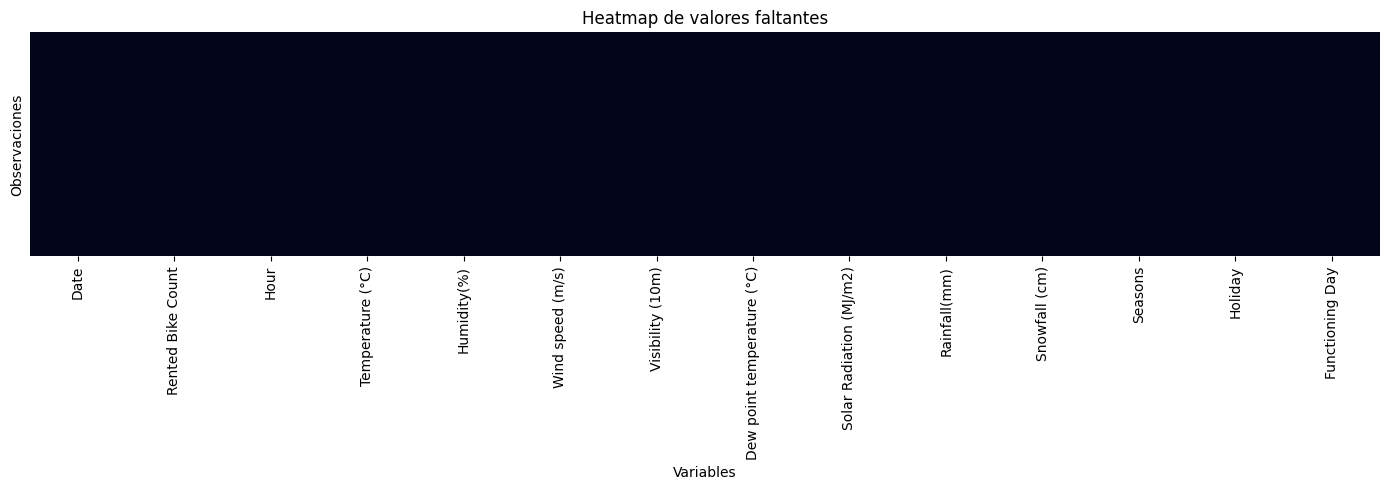

In [108]:
nulos = df.isna().sum()

tabla_nulos = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje_nulos": (nulos / len(df) * 100)
}).sort_values("Porcentaje_nulos", ascending=False)

display(tabla_nulos)

plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Heatmap de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
guardar_figura("01_missing_values_heatmap.png")


### Decisión sobre valores faltantes

El dataset original de UCI no debería contener valores faltantes. Si la ejecución confirma un 0% de nulos en todas las columnas, no se eliminarán observaciones ni variables por este motivo. De todas formas, el pipeline de preprocesamiento incluirá `SimpleImputer` con mediana para variables numéricas y moda para categóricas, de modo que el procedimiento sea robusto ante eventuales valores faltantes futuros sin ajustar ninguna transformación sobre el conjunto de test.


## 4. Detección de outliers mediante IQR

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N_outliers,%_outliers
6,Solar Radiation (MJ/m2),0.00,0.93,0.93,-1.395,2.325,641,7.317352
7,Rainfall(mm),0.00,0.00,0.00,0.000,0.000,528,6.027397
8,Snowfall (cm),0.00,0.00,0.00,0.000,0.000,443,5.057078
3,Wind speed (m/s),0.90,2.30,1.40,-1.200,4.400,161,1.837900
0,Hour,5.75,17.25,11.50,-11.500,34.500,0,0.000000
4,Visibility (10m),940.00,2000.00,1060.00,-650.000,3590.000,0,0.000000
2,Humidity(%),42.00,74.00,32.00,-6.000,122.000,0,0.000000
1,Temperature (°C),3.50,22.50,19.00,-25.000,51.000,0,0.000000
5,Dew point temperature (°C),-4.70,14.80,19.50,-33.950,44.050,0,0.000000


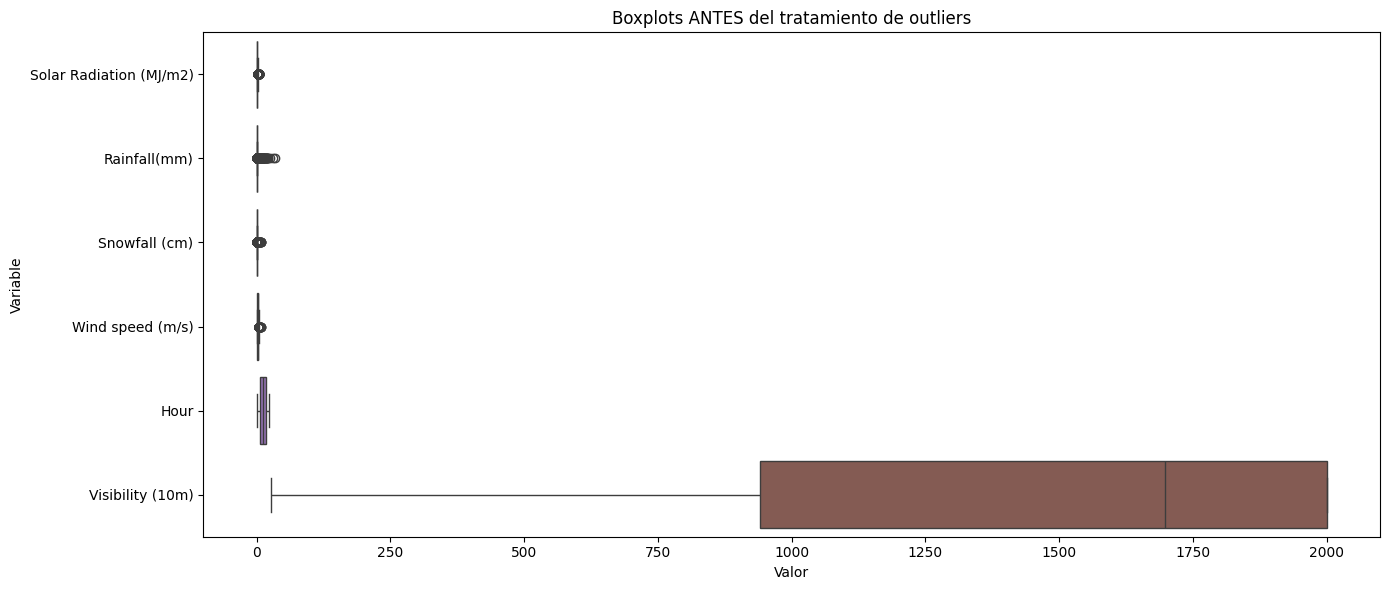

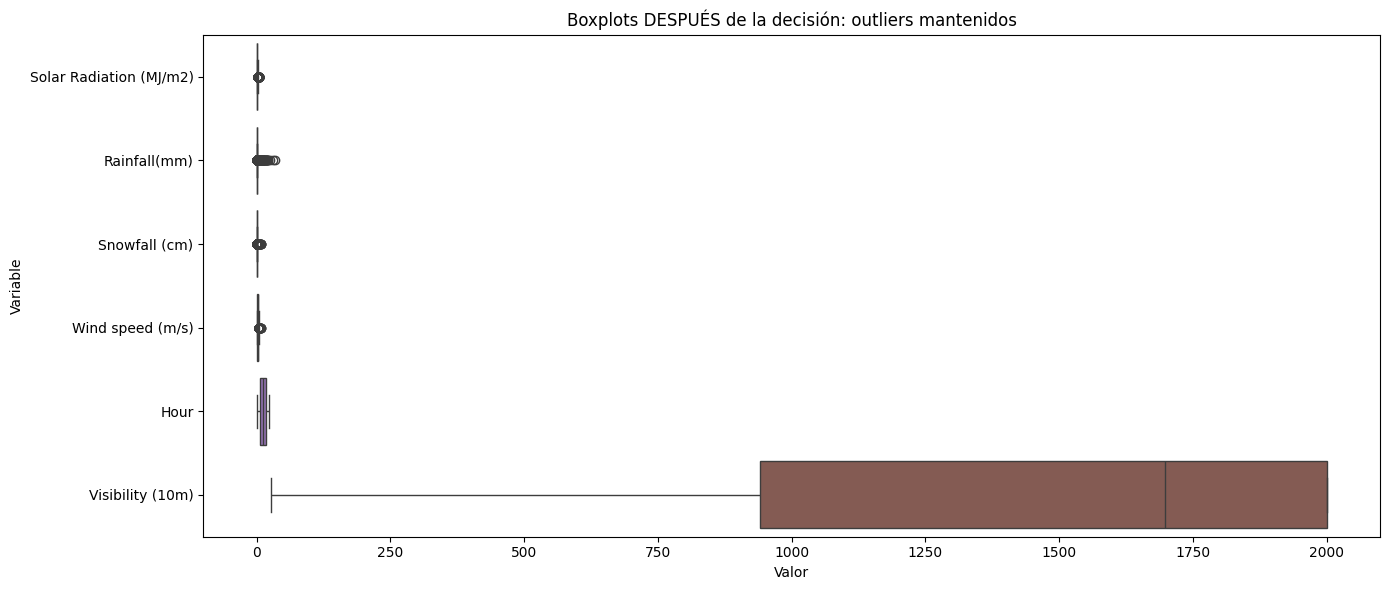

In [109]:
target = "Rented Bike Count"

numeric_eda = df.select_dtypes(include=np.number).columns.tolist()
numeric_predictors_eda = [c for c in numeric_eda if c != target]

def resumen_outliers_iqr(data, columnas):
    filas = []
    for col in columnas:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        li = q1 - 1.5 * iqr
        ls = q3 + 1.5 * iqr
        mask = (data[col] < li) | (data[col] > ls)
        filas.append({
            "Variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Límite inferior": li,
            "Límite superior": ls,
            "N_outliers": int(mask.sum()),
            "%_outliers": mask.mean() * 100
        })
    return pd.DataFrame(filas).sort_values("%_outliers", ascending=False)

tabla_outliers = resumen_outliers_iqr(df, numeric_predictors_eda)
display(tabla_outliers)

variables_clave = tabla_outliers.head(6)["Variable"].tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[variables_clave], orient="h")
plt.title("Boxplots ANTES del tratamiento de outliers")
plt.xlabel("Valor")
plt.ylabel("Variable")
guardar_figura("02_boxplots_outliers_antes.png")

df_outliers_despues = df.copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_outliers_despues[variables_clave], orient="h")
plt.title("Boxplots DESPUÉS de la decisión: outliers mantenidos")
plt.xlabel("Valor")
plt.ylabel("Variable")
guardar_figura("03_boxplots_outliers_despues.png")


### Decisión sobre outliers

Los valores identificados por IQR se **mantienen**. En este problema, observaciones extremas de lluvia, radiación, viento o demanda pueden corresponder a situaciones meteorológicas y operacionales reales, por lo que eliminarlas únicamente por una regla estadística podría reducir la capacidad del modelo para representar escenarios de alta o baja demanda. La comparación de boxplots antes y después es idéntica porque la decisión metodológica es conservar estas observaciones. Para reducir la sensibilidad a escalas diferentes se aplicará `StandardScaler` a las variables numéricas dentro del pipeline, ajustándolo exclusivamente con `X_train`.


## 5. Distribución de la variable objetivo y skewness

Skewness de Rented Bike Count: 1.1534


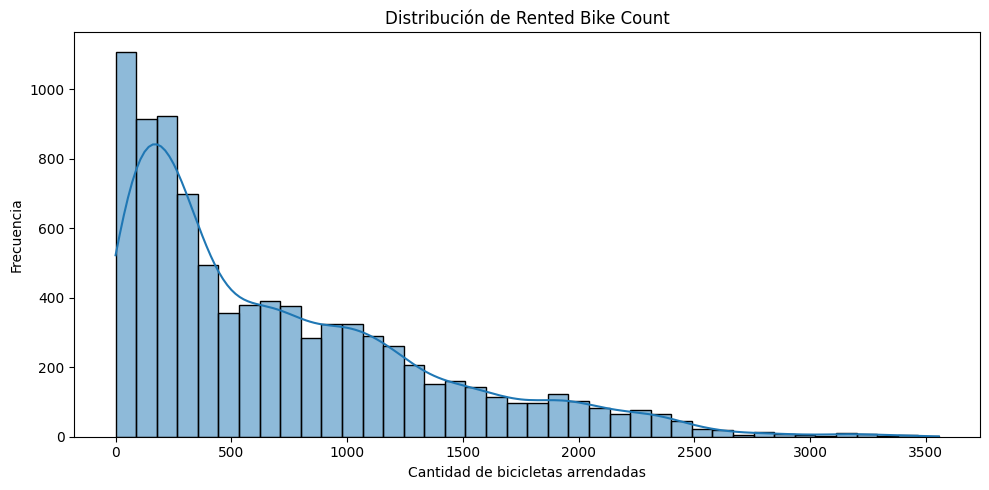

Skewness después de log1p: -1.8322


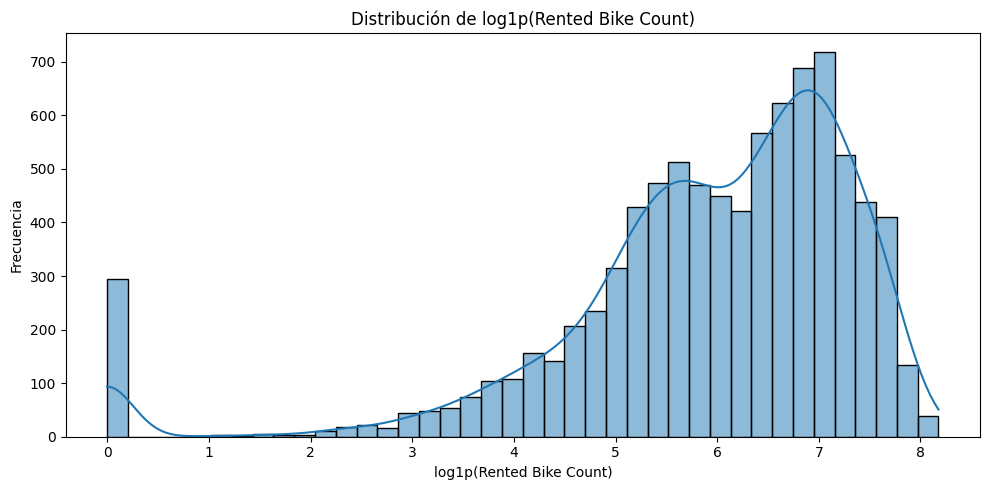

In [110]:
skew_target = df[target].skew()
print(f"Skewness de {target}: {skew_target:.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(df[target], kde=True, bins=40)
plt.title("Distribución de Rented Bike Count")
plt.xlabel("Cantidad de bicicletas arrendadas")
plt.ylabel("Frecuencia")
guardar_figura("04_target_hist_kde.png")

if skew_target > 1.0:
    target_log = np.log1p(df[target])
    skew_log = target_log.skew()
    print(f"Skewness después de log1p: {skew_log:.4f}")

    plt.figure(figsize=(10, 5))
    sns.histplot(target_log, kde=True, bins=40)
    plt.title("Distribución de log1p(Rented Bike Count)")
    plt.xlabel("log1p(Rented Bike Count)")
    plt.ylabel("Frecuencia")
    guardar_figura("05_target_log_hist_kde.png")
else:
    print("El skewness no supera 1.0; no es obligatorio evaluar transformación logarítmica.")


### Evaluación de transformación logarítmica

Si el skewness supera 1,0, se compara la distribución original con `log1p(Rented Bike Count)`. La decisión definitiva de aplicar o no la transformación durante el modelado se tomará **después del train/test split**, utilizando únicamente `y_train`. Cuando corresponda, se empleará `TransformedTargetRegressor`, que aplica la transformación al entrenamiento y devuelve las predicciones nuevamente en la escala original.


## 6. Visualizaciones exploratorias y correlaciones

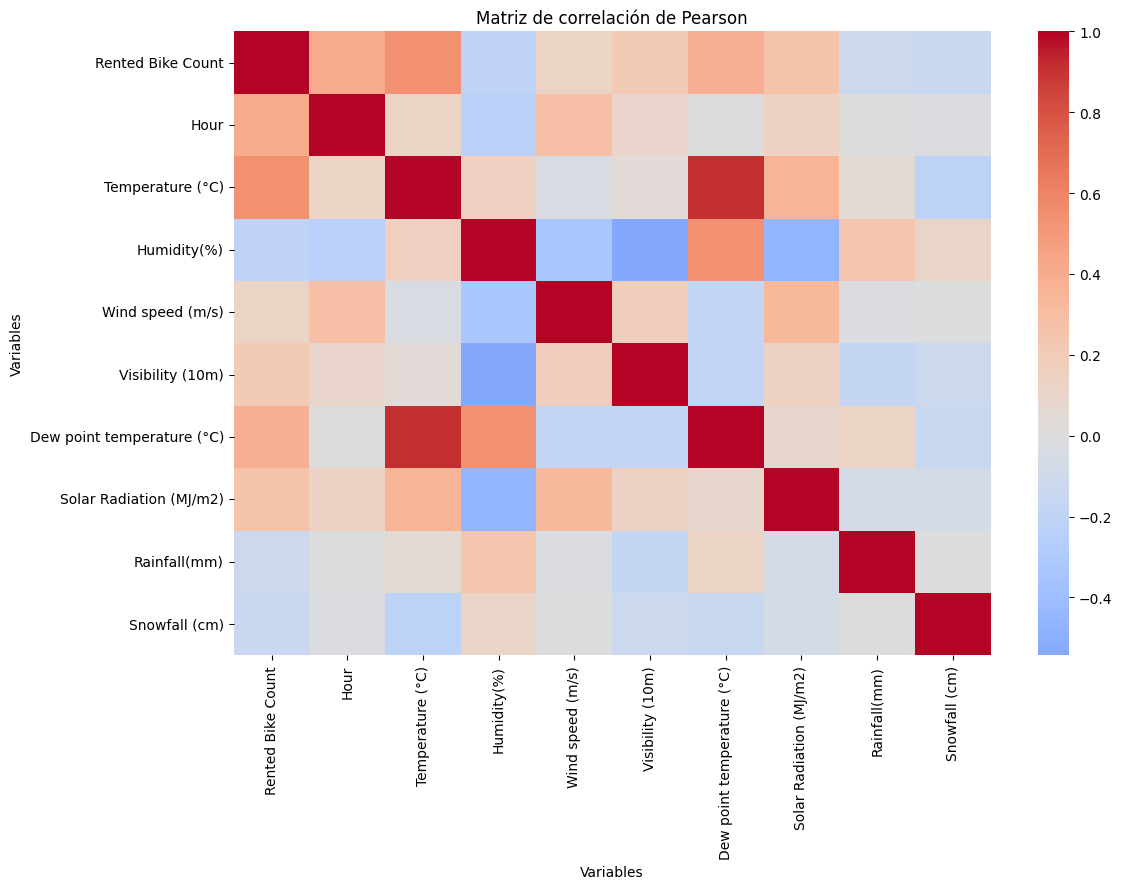

Correlaciones con la variable objetivo:


,Correlación
Temperature (°C),0.538558
Hour,0.410257
Dew point temperature (°C),0.379788
Solar Radiation (MJ/m2),0.261837
Humidity(%),-0.199780
Visibility (10m),0.199280
Snowfall (cm),-0.141804
Rainfall(mm),-0.123074
Wind speed (m/s),0.121108


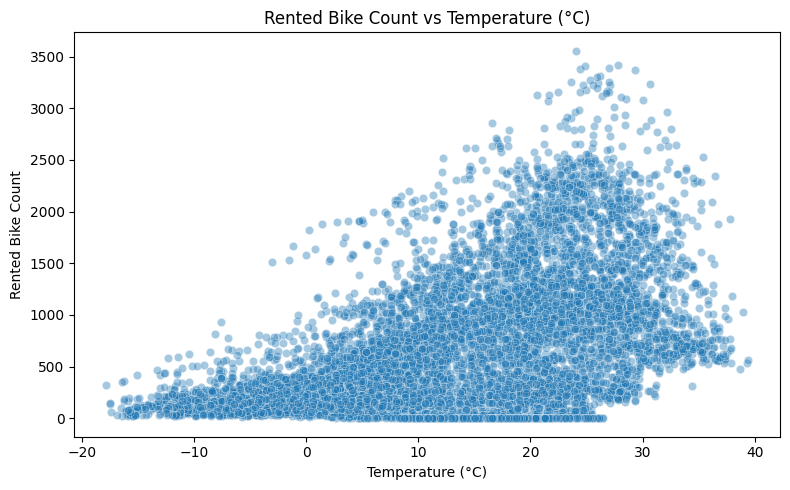

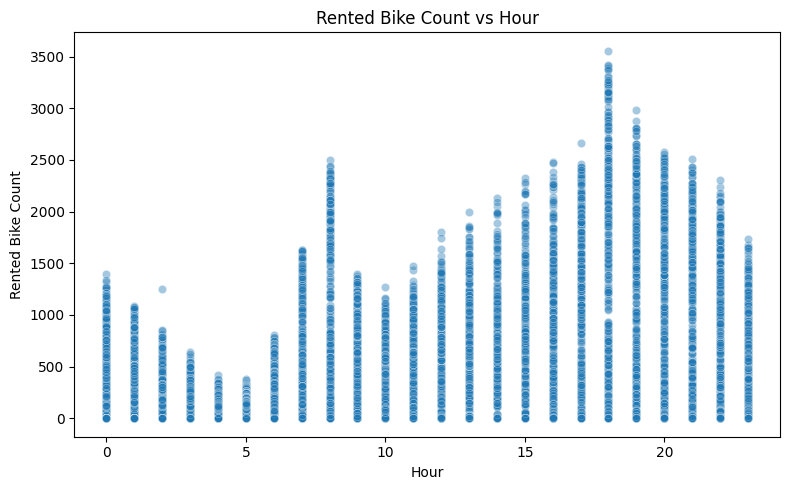

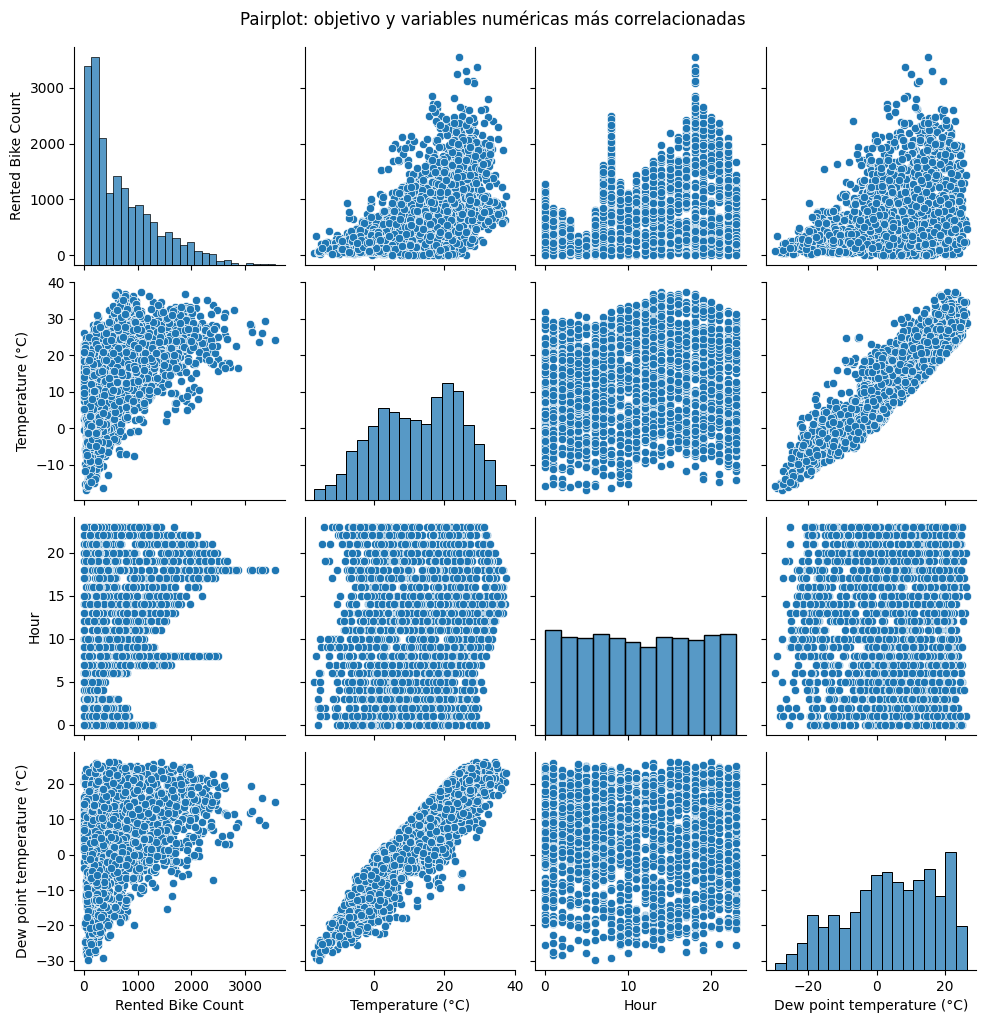

In [111]:
corr = df.select_dtypes(include=np.number).corr(method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación de Pearson")
plt.xlabel("Variables")
plt.ylabel("Variables")
guardar_figura("06_heatmap_correlacion_pearson.png")

corr_target = corr[target].drop(target).sort_values(key=np.abs, ascending=False)
print("Correlaciones con la variable objetivo:")
display(corr_target.to_frame("Correlación"))

top2 = corr_target.index[:2].tolist()

for i, col in enumerate(top2, start=1):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=col, y=target, alpha=0.4)
    plt.title(f"{target} vs {col}")
    plt.xlabel(col)
    plt.ylabel(target)
    guardar_figura(f"07_scatter_top{i}_{col.replace(' ', '_').replace('/', '_')}.png")

pair_cols = [target] + corr_target.index[:3].tolist()
g = sns.pairplot(df[pair_cols].sample(min(2000, len(df)), random_state=RANDOM_STATE))
g.fig.suptitle("Pairplot: objetivo y variables numéricas más correlacionadas", y=1.02)
g.savefig(FIG_DIR / "08_pairplot_top_variables.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Top-5 correlaciones y multicolinealidad

In [112]:
top5_corr = corr_target.head(5).to_frame("Correlación")
top5_corr["Valor absoluto"] = top5_corr["Correlación"].abs()
print("Cinco variables numéricas más correlacionadas con el objetivo:")
display(top5_corr)

corr_pred = corr.drop(index=target, columns=target)
pares_multi = []
cols = corr_pred.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_pred.iloc[i, j]
        if abs(r) > 0.85:
            pares_multi.append((cols[i], cols[j], r))

multi_df = pd.DataFrame(pares_multi, columns=["Variable 1", "Variable 2", "r"])
if len(multi_df):
    multi_df["|r|"] = multi_df["r"].abs()
    multi_df = multi_df.sort_values("|r|", ascending=False)
    print("Pares con posible multicolinealidad (|r| > 0.85):")
    display(multi_df)
else:
    print("No se detectaron pares de predictores numéricos con |r| > 0.85.")


Cinco variables numéricas más correlacionadas con el objetivo:


,Correlación,Valor absoluto
Temperature (°C),0.538558,0.538558
Hour,0.410257,0.410257
Dew point temperature (°C),0.379788,0.379788
Solar Radiation (MJ/m2),0.261837,0.261837
Humidity(%),-0.199780,0.199780


Pares con posible multicolinealidad (|r| > 0.85):


,Variable 1,Variable 2,r,|r|
0,Temperature (°C),Dew point temperature (°C),0.912798,0.912798


## 8. División train/test ANTES del preprocesamiento

In [113]:
X = df.drop(columns=[target, "Date"])
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Dimensiones:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Dimensiones:
X_train: (7008, 12)
X_test : (1752, 12)
y_train: (7008,)
y_test : (1752,)


### Feature engineering posterior al split

Para demostrar correctamente el uso de `OrdinalEncoder`, se crea una variable categórica ordinal llamada `Hour_period` a partir de `Hour`. La transformación se realiza **después del split** y se aplica por separado a train y test. El orden definido es: Madrugada → Mañana → Tarde → Noche.


In [114]:
def agregar_periodo_hora(data):
    out = data.copy()
    out["Hour_period"] = pd.cut(
        out["Hour"],
        bins=[-1, 5, 11, 17, 23],
        labels=["Madrugada", "Mañana", "Tarde", "Noche"]
    ).astype("object")
    return out

X_train_fe = agregar_periodo_hora(X_train)
X_test_fe = agregar_periodo_hora(X_test)

display(X_train_fe.head())


,Hour,Temperature (°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature (°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Hour_period
8415,15,13.2,61,3.9,719,5.8,1.03,0.0,0.0,Autumn,No Holiday,Yes,Tarde
5049,9,22.9,86,1.7,538,20.4,0.76,0.0,0.0,Summer,No Holiday,Yes,Mañana
8395,19,11.2,46,1.4,869,0.0,0.00,0.0,0.0,Autumn,No Holiday,Yes,Noche
1535,23,-2.6,69,2.0,1434,-7.5,0.00,0.0,0.0,Winter,No Holiday,Yes,Noche
5518,22,27.2,73,1.5,1005,21.9,0.00,0.0,0.0,Summer,No Holiday,Yes,Noche


## 9. ColumnTransformer: imputación, encoding y escalamiento

In [115]:
numeric_features = X_train_fe.select_dtypes(include=np.number).columns.tolist()
nominal_features = ["Seasons", "Holiday", "Functioning Day"]
ordinal_features = ["Hour_period"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=[["Madrugada", "Mañana", "Tarde", "Noche"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("nominal", nominal_pipeline, nominal_features),
        ("ordinal", ordinal_pipeline, ordinal_features)
    ],
    remainder="drop"
)

X_train_prep = preprocessor.fit_transform(X_train_fe)
X_test_prep = preprocessor.transform(X_test_fe)

feature_names = preprocessor.get_feature_names_out()

print("X_train preprocesado:", X_train_prep.shape)
print("X_test preprocesado :", X_test_prep.shape)
print("Cantidad de features después del encoding:", len(feature_names))


X_train preprocesado: (7008, 18)
X_test preprocesado : (1752, 18)
Cantidad de features después del encoding: 18


## 10. PCA: varianza explicada, scree plot y selección de componentes

,Componente,Varianza_explicada,Varianza_acumulada
0,1,2.515089e-01,0.251509
1,2,2.162693e-01,0.467778
2,3,1.457155e-01,0.613494
3,4,9.160923e-02,0.705103
4,5,8.326140e-02,0.788364
5,6,7.013221e-02,0.858497
6,7,5.758916e-02,0.916086
7,8,2.313212e-02,0.939218
8,9,2.083329e-02,0.960051
9,10,1.829723e-02,0.978348


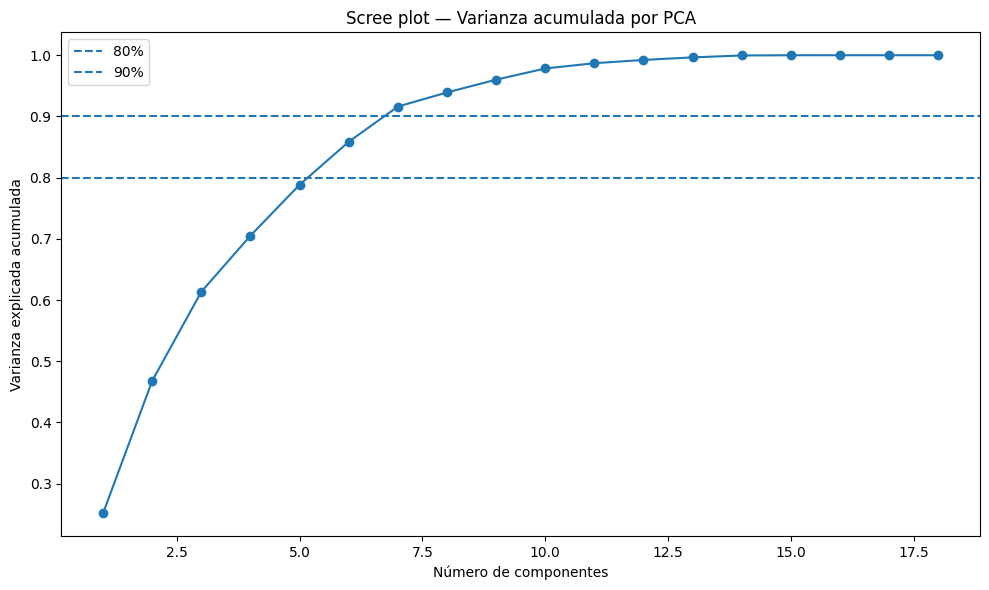

n_components seleccionado: 6
Varianza acumulada: 85.8497%


In [116]:
pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_prep)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_table = pd.DataFrame({
    "Componente": np.arange(1, len(explained) + 1),
    "Varianza_explicada": explained,
    "Varianza_acumulada": cumulative
})

display(pca_table)

plt.figure(figsize=(10, 6))
plt.plot(pca_table["Componente"], pca_table["Varianza_acumulada"], marker="o")
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.title("Scree plot — Varianza acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.legend()
guardar_figura("09_pca_scree_plot.png")

candidatos = pca_table[
    (pca_table["Varianza_acumulada"] >= 0.80) &
    (pca_table["Varianza_acumulada"] <= 0.90)
]

if len(candidatos):
    n_components = int(candidatos.iloc[0]["Componente"])
else:
    n_components = int(np.searchsorted(cumulative, 0.80) + 1)

print(f"n_components seleccionado: {n_components}")
print(f"Varianza acumulada: {cumulative[n_components-1]:.4%}")


### Criterio de selección de `n_components`

Se selecciona el menor número de componentes que permita explicar al menos el 80% de la varianza y que, cuando sea posible, se mantenga dentro del rango 80%–90%. De esta forma se reduce la dimensionalidad sin perder una proporción excesiva de información.


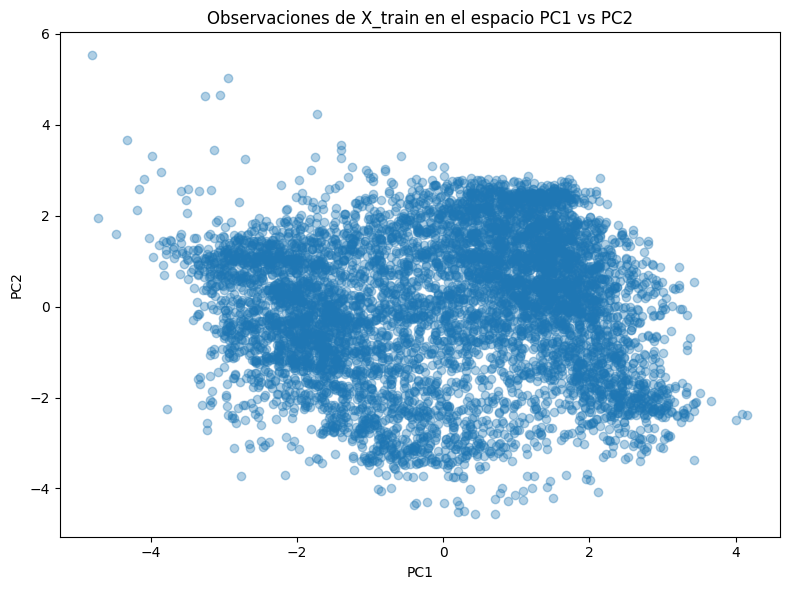

In [117]:
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_prep)
X_test_pca = pca.transform(X_test_prep)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.35)
plt.title("Observaciones de X_train en el espacio PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
guardar_figura("10_pca_pc1_pc2.png")


## 11. Loadings: variables con mayor contribución a PC1 y PC2

In [118]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(5)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(5)

print("Top-5 contribuciones absolutas a PC1:")
display(loadings.loc[top_pc1.index, ["PC1"]].sort_values("PC1", key=np.abs, ascending=False))

print("Top-5 contribuciones absolutas a PC2:")
display(loadings.loc[top_pc2.index, ["PC2"]].sort_values("PC2", key=np.abs, ascending=False))


Top-5 contribuciones absolutas a PC1:


,PC1
ordinal__Hour_period,0.515763
num__Hour,0.459193
num__Humidity(%),-0.440063
num__Wind speed (m/s),0.343991
num__Visibility (10m),0.279336


Top-5 contribuciones absolutas a PC2:


,PC2
num__Temperature (°C),0.597791
num__Dew point temperature (°C),0.591636
ordinal__Hour_period,0.239457
num__Hour,0.214578
num__Humidity(%),0.206093


## 12. K-Means para K=2...10: inercia y Silhouette Score

,K,Inercia,Silhouette
0,2,51434.716487,0.268224
1,3,43164.127707,0.262256
2,4,37172.530118,0.278749
3,5,31820.802900,0.296006
4,6,27320.670629,0.304859
5,7,24150.658192,0.288278
6,8,21698.770762,0.287516
7,9,19854.282564,0.289520
8,10,18521.510924,0.293803


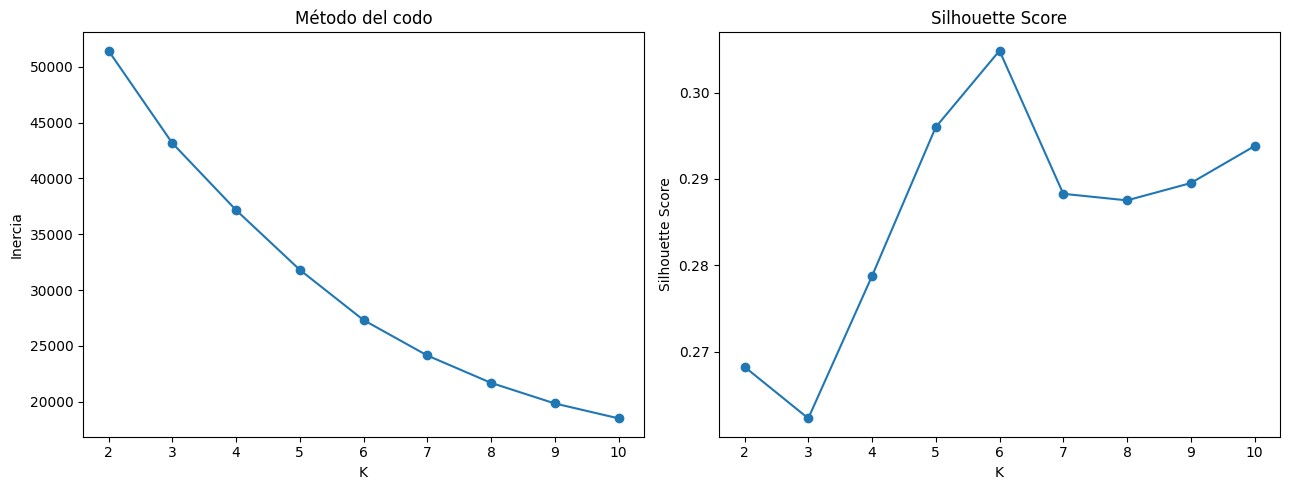

K óptimo según máximo Silhouette Score: 6
Silhouette Score: 0.3049


In [119]:
k_values = range(2, 11)
inercias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_pca)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_pca, labels))

kmeans_eval = pd.DataFrame({
    "K": list(k_values),
    "Inercia": inercias,
    "Silhouette": silhouettes
})
display(kmeans_eval)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(kmeans_eval["K"], kmeans_eval["Inercia"], marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inercia")

axes[1].plot(kmeans_eval["K"], kmeans_eval["Silhouette"], marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig(FIG_DIR / "11_kmeans_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

k_opt = int(kmeans_eval.loc[kmeans_eval["Silhouette"].idxmax(), "K"])
sil_opt = float(kmeans_eval["Silhouette"].max())

print(f"K óptimo según máximo Silhouette Score: {k_opt}")
print(f"Silhouette Score: {sil_opt:.4f}")


### Selección de K

Se utiliza como criterio principal el **máximo Silhouette Score**, complementado con la inspección visual del método del codo. El valor seleccionado debe producir grupos internamente cohesionados y razonablemente separados, evitando elegir un número de clusters innecesariamente alto.


## 13. Clusters finales y perfil de clusters

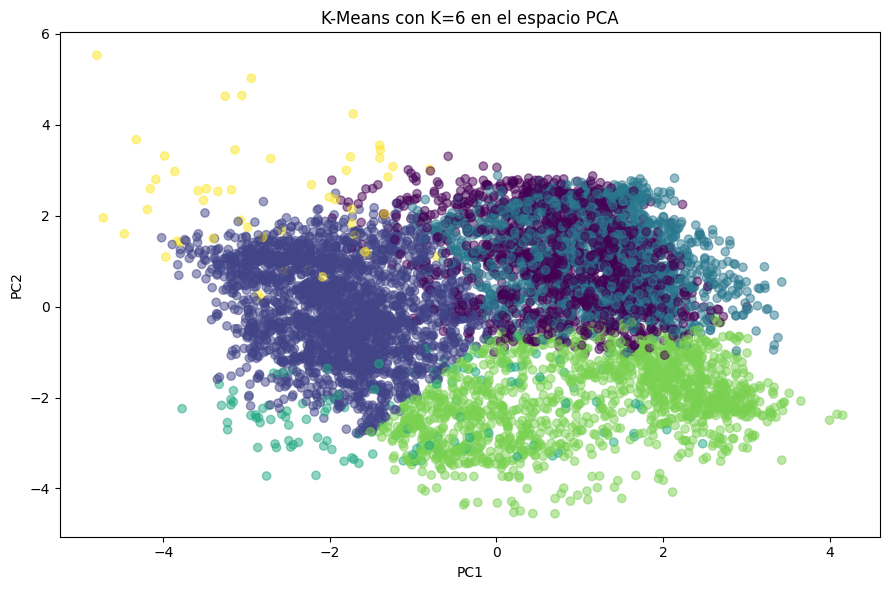

Media de variables numéricas por cluster:


,Hour,Temperature (°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature (°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Cluster,,,,,,,,,
0,19.669765,16.429678,64.410161,1.736493,1343.277571,9.155019,0.143024,0.117844,0.016047
1,4.584082,13.833890,72.870774,1.120197,1210.602910,8.788832,0.124185,0.111596,0.016731
2,13.389610,23.432194,43.961039,2.328640,1643.301435,9.873753,1.972734,0.002324,0.000000
3,10.384615,-1.347692,74.007692,1.428462,926.953846,-5.772308,0.215077,0.172308,2.936923
4,11.796598,-2.289157,38.680369,2.156060,1786.568391,-14.968462,0.423267,0.000496,0.066832
5,11.698113,17.326415,96.018868,1.394340,501.905660,16.637736,0.070566,9.900000,0.000000


Moda de variables categóricas por cluster:


,Seasons,Holiday,Functioning Day,Hour_period
Cluster,,,,
0,Autumn,No Holiday,Yes,Noche
1,Spring,No Holiday,Yes,Madrugada
2,Summer,No Holiday,Yes,Tarde
3,Winter,No Holiday,Yes,Mañana
4,Winter,No Holiday,Yes,Tarde
5,Summer,No Holiday,Yes,Mañana


### Interpretación automática del perfil de clusters

Las variables numéricas que más diferencian los clusters son: Rainfall(mm), Snowfall (cm), Humidity(%). Para Rainfall(mm), el cluster 5 presenta la media más alta (9.90) y el cluster 4 la más baja (0.00). Para Snowfall (cm), el cluster 3 presenta la media más alta (2.94) y el cluster 2 la más baja (0.00). Para Humidity(%), el cluster 5 presenta la media más alta (96.02) y el cluster 4 la más baja (38.68). 

In [120]:
kmeans_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
cluster_train = kmeans_final.fit_predict(X_train_pca)

plt.figure(figsize=(9, 6))
plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=cluster_train,
    alpha=0.5
)
plt.title(f"K-Means con K={k_opt} en el espacio PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
guardar_figura("12_clusters_pca.png")

perfil = X_train_fe.copy()
perfil["Cluster"] = cluster_train

numeric_profile_cols = perfil.select_dtypes(include=np.number).columns.tolist()
numeric_profile_cols = [c for c in numeric_profile_cols if c != "Cluster"]

perfil_medias = perfil.groupby("Cluster")[numeric_profile_cols].mean()
print("Media de variables numéricas por cluster:")
display(perfil_medias)

categorical_profile_cols = nominal_features + ordinal_features
print("Moda de variables categóricas por cluster:")
perfil_moda = perfil.groupby("Cluster")[categorical_profile_cols].agg(
    lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
)
display(perfil_moda)

std_global = X_train_fe[numeric_profile_cols].std().replace(0, np.nan)
rango_normalizado = (
    (perfil_medias.max() - perfil_medias.min()) / std_global
).sort_values(ascending=False)

top_cluster_drivers = rango_normalizado.head(3).index.tolist()

texto_cluster = "Las variables numéricas que más diferencian los clusters son: " + ", ".join(top_cluster_drivers) + ". "
for v in top_cluster_drivers:
    cmax = int(perfil_medias[v].idxmax())
    cmin = int(perfil_medias[v].idxmin())
    texto_cluster += (
        f"Para {v}, el cluster {cmax} presenta la media más alta "
        f"({perfil_medias.loc[cmax, v]:.2f}) y el cluster {cmin} la más baja "
        f"({perfil_medias.loc[cmin, v]:.2f}). "
    )

display(Markdown("### Interpretación automática del perfil de clusters\n\n" + texto_cluster))


## 14. Decisión de transformación del target usando solo y_train

In [121]:
skew_train = y_train.skew()
use_log_target = skew_train > 1.0

print(f"Skewness de y_train: {skew_train:.4f}")
print("¿Se usará log1p en el target?:", use_log_target)

if use_log_target:
    print(f"Skewness log1p(y_train): {np.log1p(y_train).skew():.4f}")


Skewness de y_train: 1.1539
¿Se usará log1p en el target?: True
Skewness log1p(y_train): -1.8268


## 15. Modelo penalizado: Ridge

In [122]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

if use_log_target:
    ridge_base = TransformedTargetRegressor(
        regressor=Ridge(),
        func=np.log1p,
        inverse_func=np.expm1
    )
    ridge_grid = {"regressor__alpha": alphas}
else:
    ridge_base = Ridge()
    ridge_grid = {"alpha": alphas}

ridge_search = GridSearchCV(
    estimator=ridge_base,
    param_grid=ridge_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

t0 = time.time()
ridge_search.fit(X_train_prep, y_train)
ridge_train_time = time.time() - t0

print("Mejor parámetro Ridge:")
print(ridge_search.best_params_)
print(f"Mejor RMSE CV: {-ridge_search.best_score_:.4f}")
print(f"Tiempo de entrenamiento/búsqueda: {ridge_train_time:.4f} s")


Mejor parámetro Ridge:
{'regressor__alpha': 10}
Mejor RMSE CV: 434.2558
Tiempo de entrenamiento/búsqueda: 2.5230 s


## 16. Modelo basado en árboles: Random Forest

In [123]:
rf_inner = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

if use_log_target:
    rf_base = TransformedTargetRegressor(
        regressor=rf_inner,
        func=np.log1p,
        inverse_func=np.expm1
    )
    rf_grid = {
        "regressor__n_estimators": [100, 200],
        "regressor__max_depth": [None, 10, 20],
        "regressor__min_samples_split": [2, 5]
    }
else:
    rf_base = rf_inner
    rf_grid = {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    }

rf_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

t0 = time.time()
rf_search.fit(X_train_prep, y_train)
rf_train_time = time.time() - t0

print("Mejores hiperparámetros Random Forest:")
print(rf_search.best_params_)
print(f"Mejor RMSE CV: {-rf_search.best_score_:.4f}")
print(f"Tiempo de entrenamiento/búsqueda: {rf_train_time:.4f} s")


Mejores hiperparámetros Random Forest:
{'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Mejor RMSE CV: 237.3529
Tiempo de entrenamiento/búsqueda: 318.9668 s


## 17. Predicciones, métricas TEST y tiempo de inferencia

In [124]:
def mape_seguro(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def metricas_regresion(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mape_seguro(y_true, y_pred)
    }

modelos = {
    "Ridge": ridge_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_
}

train_times = {
    "Ridge": ridge_train_time,
    "Random Forest": rf_train_time
}

pred_test = {}
pred_train = {}
filas_resultados = []

for nombre, modelo in modelos.items():
    t0 = time.time()
    y_pred_test = modelo.predict(X_test_prep)
    infer_time = time.time() - t0

    y_pred_train = modelo.predict(X_train_prep)

    y_pred_test = np.clip(y_pred_test, 0, None)
    y_pred_train = np.clip(y_pred_train, 0, None)

    pred_test[nombre] = y_pred_test
    pred_train[nombre] = y_pred_train

    m_test = metricas_regresion(y_test, y_pred_test)
    m_train = metricas_regresion(y_train, y_pred_train)

    filas_resultados.append({
        "Modelo": nombre,
        "RMSE": m_test["RMSE"],
        "MAE": m_test["MAE"],
        "R2": m_test["R2"],
        "MAPE": m_test["MAPE"],
        "RMSE_train": m_train["RMSE"],
        "R2_train": m_train["R2"],
        "Tiempo_entrenamiento_s": train_times[nombre],
        "Tiempo_inferencia_s": infer_time
    })

resultados = pd.DataFrame(filas_resultados).sort_values("RMSE").reset_index(drop=True)

display(resultados.round(4))

resultados.to_csv("resultados_modelos.csv", index=False)
print("Tabla exportada como resultados_modelos.csv")
print("Nota: MAPE se calcula excluyendo observaciones con y_true=0, porque MAPE no está definido cuando el valor real es cero.")


,Modelo,RMSE,MAE,R2,MAPE,RMSE_train,R2_train,Tiempo_entrenamiento_s,Tiempo_inferencia_s
0,Random Forest,255.1746,146.7562,0.8437,32.0579,103.5629,0.9742,318.9668,0.1353
1,Ridge,440.8677,278.7079,0.5335,69.9315,432.7759,0.5496,2.5230,0.0020


Tabla exportada como resultados_modelos.csv
Nota: MAPE se calcula excluyendo observaciones con y_true=0, porque MAPE no está definido cuando el valor real es cero.


## 18. Valores reales vs predichos e histogramas de residuales

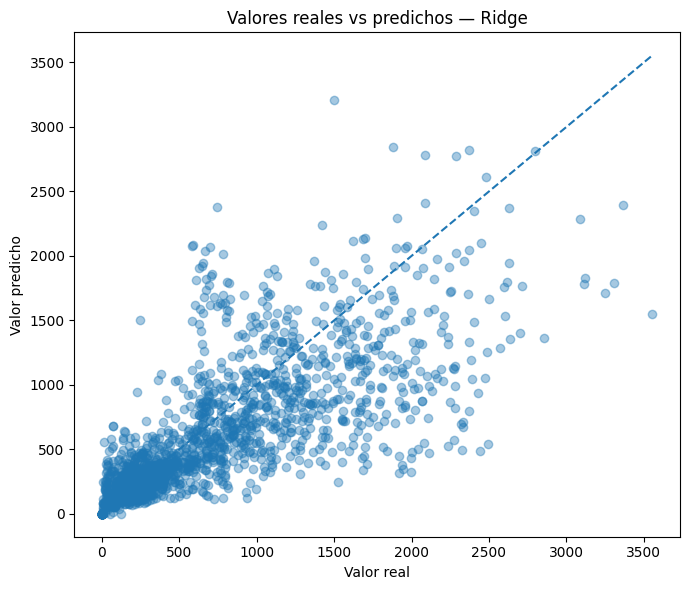

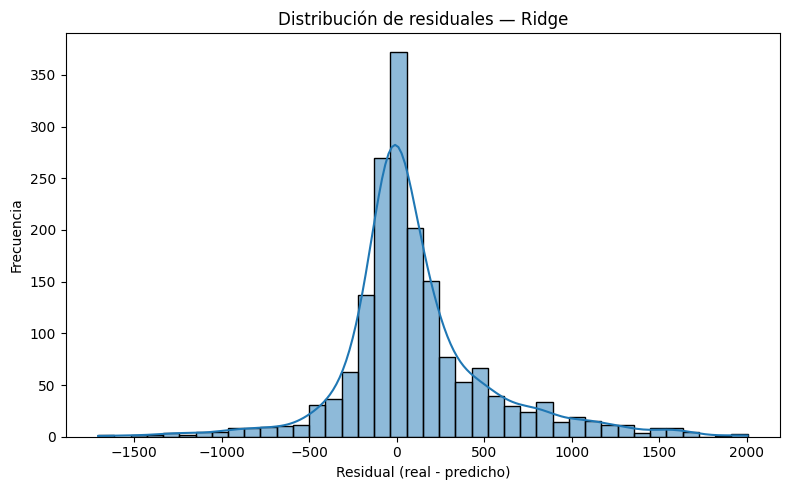

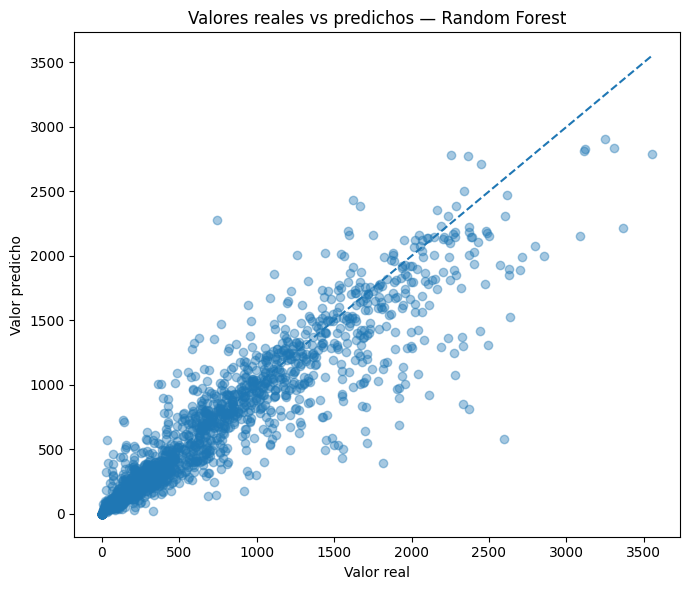

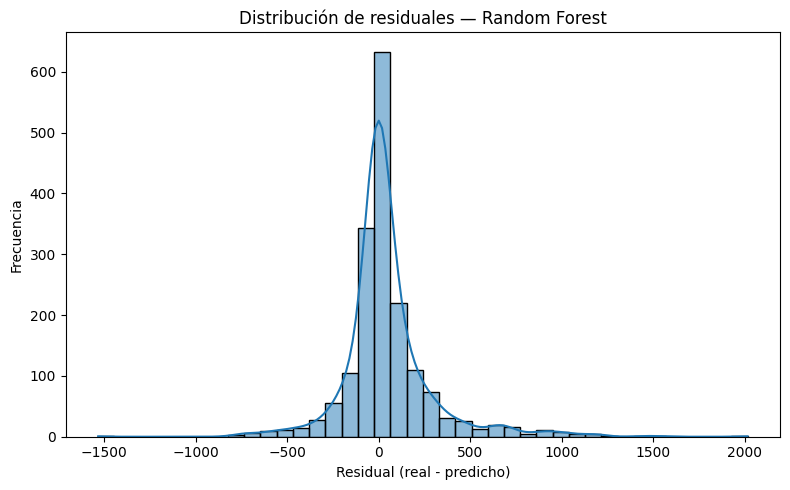

In [125]:
for nombre, y_pred in pred_test.items():
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test, y_pred, alpha=0.4)
    minimo = min(y_test.min(), y_pred.min())
    maximo = max(y_test.max(), y_pred.max())
    plt.plot([minimo, maximo], [minimo, maximo], linestyle="--")
    plt.title(f"Valores reales vs predichos — {nombre}")
    plt.xlabel("Valor real")
    plt.ylabel("Valor predicho")
    guardar_figura(f"13_reales_vs_predichos_{nombre.replace(' ', '_')}.png")

    residuales = y_test.to_numpy() - y_pred
    plt.figure(figsize=(8, 5))
    sns.histplot(residuales, kde=True, bins=40)
    plt.title(f"Distribución de residuales — {nombre}")
    plt.xlabel("Residual (real - predicho)")
    plt.ylabel("Frecuencia")
    guardar_figura(f"14_residuales_{nombre.replace(' ', '_')}.png")


## 19. Selección y justificación del mejor modelo

In [126]:
best_name = resultados.iloc[0]["Modelo"]
best_model = modelos[best_name]
best_row = resultados.iloc[0]
other_row = resultados.iloc[1]

rmse_gap = best_row["RMSE"] - best_row["RMSE_train"]
overfit_text = (
    "existe una brecha relevante entre entrenamiento y test, lo que sugiere cierto grado de sobreajuste"
    if best_row["RMSE"] > best_row["RMSE_train"] * 1.20
    else "la diferencia entre entrenamiento y test es acotada, por lo que no se observa una señal fuerte de sobreajuste"
)

texto_150 = f'''
### Justificación del modelo seleccionado

El modelo seleccionado es **{best_name}**, porque obtuvo el menor RMSE sobre el conjunto de test
(**{best_row["RMSE"]:.4f}**) y un R² de **{best_row["R2"]:.4f}**. En comparación, el otro modelo,
**{other_row["Modelo"]}**, obtuvo un RMSE de **{other_row["RMSE"]:.4f}** y un R² de
**{other_row["R2"]:.4f}**. La evaluación se realiza exclusivamente con datos que no fueron utilizados
para ajustar el preprocesamiento ni los modelos. Al comparar el RMSE de entrenamiento
(**{best_row["RMSE_train"]:.4f}**) con el de test, {overfit_text}. Desde el punto de vista del trade-off
entre desempeño e interpretabilidad, Ridge ofrece coeficientes directamente analizables, mientras
que Random Forest puede capturar relaciones no lineales e interacciones más complejas a costa de
una menor transparencia estructural. El tiempo total de búsqueda y entrenamiento del mejor modelo
fue de **{best_row["Tiempo_entrenamiento_s"]:.4f} segundos**, y su tiempo de inferencia sobre el
conjunto de test fue de **{best_row["Tiempo_inferencia_s"]:.4f} segundos**. Por lo tanto, la elección
no se basa únicamente en una métrica aislada, sino en el equilibrio entre capacidad predictiva,
generalización, interpretabilidad y costo computacional. Para un sistema de planificación de
bicicletas, un RMSE menor permite estimar con mayor precisión la demanda horaria y apoyar decisiones
de disponibilidad y redistribución.
'''
display(Markdown(texto_150))



### Justificación del modelo seleccionado

El modelo seleccionado es **Random Forest**, porque obtuvo el menor RMSE sobre el conjunto de test
(**255.1746**) y un R² de **0.8437**. En comparación, el otro modelo,
**Ridge**, obtuvo un RMSE de **440.8677** y un R² de
**0.5335**. La evaluación se realiza exclusivamente con datos que no fueron utilizados
para ajustar el preprocesamiento ni los modelos. Al comparar el RMSE de entrenamiento
(**103.5629**) con el de test, existe una brecha relevante entre entrenamiento y test, lo que sugiere cierto grado de sobreajuste. Desde el punto de vista del trade-off
entre desempeño e interpretabilidad, Ridge ofrece coeficientes directamente analizables, mientras
que Random Forest puede capturar relaciones no lineales e interacciones más complejas a costa de
una menor transparencia estructural. El tiempo total de búsqueda y entrenamiento del mejor modelo
fue de **318.9668 segundos**, y su tiempo de inferencia sobre el
conjunto de test fue de **0.1353 segundos**. Por lo tanto, la elección
no se basa únicamente en una métrica aislada, sino en el equilibrio entre capacidad predictiva,
generalización, interpretabilidad y costo computacional. Para un sistema de planificación de
bicicletas, un RMSE menor permite estimar con mayor precisión la demanda horaria y apoyar decisiones
de disponibilidad y redistribución.


## 20. Importancia de variables del mejor modelo

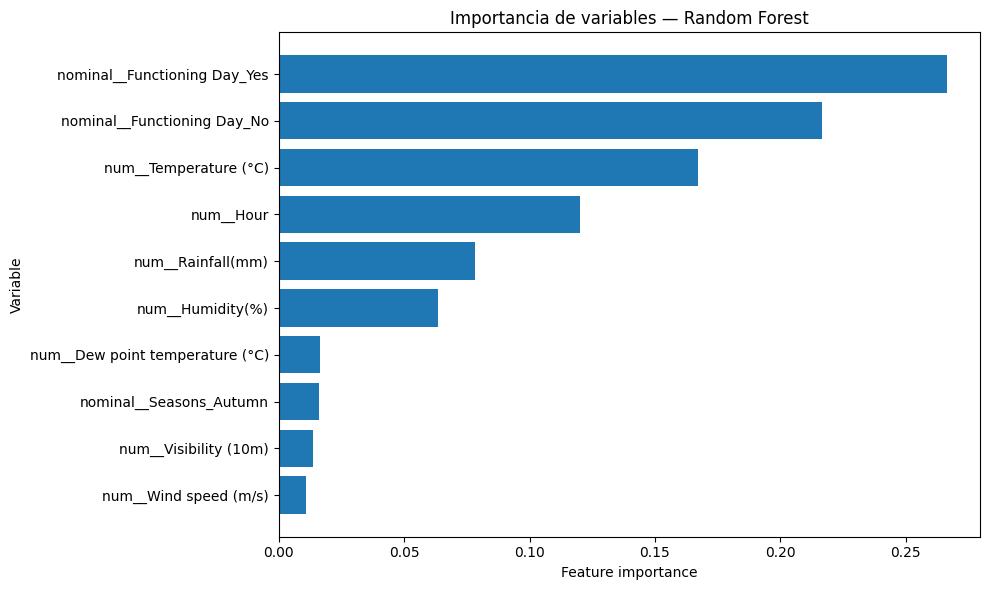

,Feature,Importancia
16,nominal__Functioning Day_Yes,0.266225
15,nominal__Functioning Day_No,0.216424
1,num__Temperature (°C),0.167169
0,num__Hour,0.119988
7,num__Rainfall(mm),0.078067
2,num__Humidity(%),0.063451
5,num__Dew point temperature (°C),0.016559
9,nominal__Seasons_Autumn,0.016007
4,num__Visibility (10m),0.013519
3,num__Wind speed (m/s),0.011082


### Interpretación de importancia y comparación con EDA

Las cinco variables/features más importantes del modelo son: nominal__Functioning Day_Yes, nominal__Functioning Day_No, num__Temperature (°C), num__Hour, num__Rainfall(mm). Por otra parte, las cinco variables numéricas con mayor correlación lineal absoluta durante el EDA fueron: Temperature (°C), Hour, Dew point temperature (°C), Solar Radiation (MJ/m2), Humidity(%). La comparación permite verificar si las relaciones lineales observadas en el EDA coinciden con las variables que el modelo considera más útiles. Las diferencias son esperables, especialmente en Random Forest, porque el modelo puede capturar interacciones y relaciones no lineales que una correlación de Pearson no representa.

In [127]:
if isinstance(best_model, TransformedTargetRegressor):
    estimador_interno = best_model.regressor_
else:
    estimador_interno = best_model

if hasattr(estimador_interno, "feature_importances_"):
    importancias = estimador_interno.feature_importances_
    tipo_importancia = "Feature importance"
elif hasattr(estimador_interno, "coef_"):
    importancias = np.abs(np.ravel(estimador_interno.coef_))
    tipo_importancia = "|Coeficiente|"
else:
    raise AttributeError("El modelo seleccionado no expone importancias ni coeficientes.")

feature_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importancia": importancias
}).sort_values("Importancia", ascending=False)

top10_imp = feature_imp.head(10).sort_values("Importancia")

plt.figure(figsize=(10, 6))
plt.barh(top10_imp["Feature"], top10_imp["Importancia"])
plt.title(f"Importancia de variables — {best_name}")
plt.xlabel(tipo_importancia)
plt.ylabel("Variable")
guardar_figura("15_feature_importance_best_model.png")

display(feature_imp.head(10))

top5_features = feature_imp.head(5)["Feature"].tolist()
top5_corr_names = top5_corr.index.tolist()

texto_features = (
    "Las cinco variables/features más importantes del modelo son: "
    + ", ".join(top5_features)
    + ". Por otra parte, las cinco variables numéricas con mayor correlación lineal absoluta durante el EDA fueron: "
    + ", ".join(top5_corr_names)
    + ". La comparación permite verificar si las relaciones lineales observadas en el EDA coinciden con las variables que el modelo considera más útiles. "
    + "Las diferencias son esperables, especialmente en Random Forest, porque el modelo puede capturar interacciones y relaciones no lineales que una correlación de Pearson no representa."
)

display(Markdown("### Interpretación de importancia y comparación con EDA\n\n" + texto_features))


## 21. Diez observaciones con mayor error

In [128]:
best_pred = pred_test[best_name]

errores = X_test_fe.copy()
errores["Real"] = y_test.values
errores["Predicho"] = best_pred
errores["Residual"] = errores["Real"] - errores["Predicho"]
errores["Error_absoluto"] = np.abs(errores["Residual"])

top10_error = errores.nlargest(10, "Error_absoluto")
display(top10_error)

num_cols_error = X_test_fe.select_dtypes(include=np.number).columns.tolist()

comparacion_error = pd.DataFrame({
    "Media_top10": top10_error[num_cols_error].mean(),
    "Media_test": X_test_fe[num_cols_error].mean(),
    "Std_test": X_test_fe[num_cols_error].std()
})
comparacion_error["Diferencia_estandarizada"] = (
    (comparacion_error["Media_top10"] - comparacion_error["Media_test"])
    / comparacion_error["Std_test"].replace(0, np.nan)
)
comparacion_error["Abs_dif"] = comparacion_error["Diferencia_estandarizada"].abs()
comparacion_error = comparacion_error.sort_values("Abs_dif", ascending=False)

display(comparacion_error.head(5))

drivers_error = comparacion_error.head(3).index.tolist()

cat_desc = []
for c in nominal_features + ordinal_features:
    if c in top10_error.columns and not top10_error[c].mode().empty:
        cat_desc.append(f"{c}={top10_error[c].mode().iloc[0]}")

texto_error = (
    "Al analizar las 10 observaciones con mayor error absoluto, "
    "las variables numéricas que más se diferencian del comportamiento general "
    "del conjunto de test son: "
    + ", ".join(drivers_error)
    + ". "
)
if cat_desc:
    texto_error +=  "En cuanto a las variables categóricas, entre estos casos predominan: " + ", ".join(cat_desc) + ". "
texto_error += (
    "Estos patrones no implican que dichas características sean la causa directa "
    "de los errores, pero permiten identificar situaciones en las que el modelo "
    "presenta mayores dificultades de predicción. Los errores más altos podrían "
    "estar asociados a combinaciones menos habituales de condiciones meteorológicas, "
    "horario y contexto operacional."
)

display(Markdown("### Características comunes de los mayores errores\n\n" + texto_error))


,Hour,Temperature (°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature (°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Hour_period,Real,Predicho,Residual,Error_absoluto
5155,19,30.4,62,0.9,2000,22.2,0.65,0.1,0.0,Summer,No Holiday,Yes,Noche,2598,582.638563,2015.361437,2015.361437
6824,8,17.8,53,1.4,2000,8.0,0.51,0.0,0.0,Autumn,No Holiday,Yes,Mañana,2369,810.530711,1558.469289,1558.469289
4794,18,29.2,35,2.7,1900,12.1,1.27,0.0,0.0,Summer,No Holiday,Yes,Noche,746,2278.058212,-1532.058212,1532.058212
6872,8,20.9,68,1.3,2000,14.7,0.18,0.0,0.0,Autumn,No Holiday,Yes,Mañana,2329,852.626928,1476.373072,1476.373072
3320,8,8.3,36,0.6,1335,-5.9,0.82,0.0,0.0,Spring,No Holiday,Yes,Mañana,1815,392.915791,1422.084209,1422.084209
3296,8,8.7,49,0.8,1520,-1.4,0.68,0.0,0.0,Spring,No Holiday,Yes,Mañana,1920,686.177323,1233.822677,1233.822677
6800,8,20.1,57,1.6,2000,11.3,0.73,0.0,0.0,Autumn,No Holiday,Yes,Mañana,2278,1073.260222,1204.739778,1204.739778
7736,8,7.9,63,0.6,2000,1.2,0.30,0.0,0.0,Autumn,No Holiday,Yes,Mañana,2113,917.601787,1195.398213,1195.398213
4640,8,19.0,67,1.1,1976,12.7,1.29,0.0,0.0,Summer,No Holiday,Yes,Mañana,2495,1309.742273,1185.257727,1185.257727
3272,8,6.9,54,0.7,1706,-1.7,0.85,0.0,0.0,Spring,No Holiday,Yes,Mañana,1713,551.831660,1161.168340,1161.168340


,Media_top10,Media_test,Std_test,Diferencia_estandarizada,Abs_dif
Visibility (10m),1843.700,1436.793379,600.041368,0.678131,0.678131
Wind speed (m/s),1.170,1.701484,1.035353,-0.513336,0.513336
Temperature (°C),16.920,12.678482,12.161930,0.348754,0.348754
Dew point temperature (°C),7.320,3.946747,13.381294,0.252087,0.252087
Solar Radiation (MJ/m2),0.728,0.541844,0.848005,0.219523,0.219523


### Características comunes de los mayores errores

Al analizar las 10 observaciones con mayor error absoluto, las variables numéricas que más se diferencian del comportamiento general del conjunto de test son: Visibility (10m), Wind speed (m/s), Temperature (°C). En cuanto a las variables categóricas, entre estos casos predominan: Seasons=Autumn, Holiday=No Holiday, Functioning Day=Yes, Hour_period=Mañana. Estos patrones no implican que dichas características sean la causa directa de los errores, pero permiten identificar situaciones en las que el modelo presenta mayores dificultades de predicción. Los errores más altos podrían estar asociados a combinaciones menos habituales de condiciones meteorológicas, horario y contexto operacional.

## 22. Conclusiones

In [129]:
top3_business = feature_imp.head(3)["Feature"].tolist()
eda_top3 = top5_corr.index[:3].tolist()

conclusion = f'''
### Conclusiones

El análisis del dataset **Seoul Bike Sharing Demand** permitió estudiar qué factores están asociados
con la demanda horaria de bicicletas públicas en Seúl y evaluar distintos métodos de Machine Learning
para predecir la cantidad de bicicletas arrendadas.

Durante el EDA se revisó la estructura de los datos, sus tipos, valores
faltantes, outliers, distribución de la variable objetivo y correlaciones. Las variables numéricas con
mayor asociación lineal absoluta con la demanda incluyeron **{eda_top3[0]}**, **{eda_top3[1]}** y
**{eda_top3[2]}**. Los outliers detectados mediante IQR se mantuvieron porque pueden representar
situaciones reales de operación o clima y no necesariamente errores de medición. Cuando la
distribución del target presentó asimetría superior a 1,0, se evaluó la transformación `log1p`,
aplicándola dentro del entrenamiento solo si `y_train` cumplía dicha condición.

El análisis no supervisado redujo la dimensionalidad mediante PCA, conservando
**{cumulative[n_components-1]:.2%}** de la varianza con **{n_components} componentes**. Posteriormente,
K-Means evaluó valores de K entre 2 y 10 utilizando inercia y Silhouette Score. El valor seleccionado
fue **K={k_opt}**, con un Silhouette Score de **{sil_opt:.4f}**. Los perfiles de cluster mostraron que
variables como **{top_cluster_drivers[0]}**, **{top_cluster_drivers[1]}** y **{top_cluster_drivers[2]}**
son relevantes para diferenciar grupos de observaciones, lo que sugiere que la demanda ocurre bajo
contextos operacionales y meteorológicos distintos.

En el modelado supervisado se compararon Ridge y Random Forest, ambos optimizados mediante
validación cruzada de cinco particiones. El mejor modelo fue **{best_name}**, con RMSE de
**{best_row["RMSE"]:.4f}**, MAE de **{best_row["MAE"]:.4f}**, R² de **{best_row["R2"]:.4f}** y MAPE
de **{best_row["MAPE"]:.4f}%** en test. Sus tres features más importantes fueron
**{top3_business[0]}**, **{top3_business[1]}** y **{top3_business[2]}**. Desde una perspectiva de
negocio, estas variables pueden utilizarse para anticipar periodos de mayor o menor demanda y apoyar
la redistribución de bicicletas entre estaciones, reduciendo el riesgo de falta de disponibilidad.

El trabajo presenta al menos tres limitaciones específicas. Primero, el dataset corresponde a una
sola ciudad y periodo, por lo que la generalización hacia otras ciudades no está garantizada.
Segundo, el `train_test_split` aleatorio es apropiado para cumplir la consigna, pero no reproduce por
completo un escenario temporal de producción, donde el futuro debe predecirse usando únicamente el
pasado. Tercero, el dataset no incorpora variables externas potencialmente importantes, como eventos
masivos, interrupciones del transporte público, capacidad de cada estación o información espacial
detallada. Además, MAPE no está definido cuando la demanda real es cero; por ello se calculó
excluyendo esos casos.

Como recomendaciones concretas, se propone **(1)** utilizar las predicciones horarias para planificar
la redistribución preventiva de bicicletas antes de las franjas de mayor demanda y **(2)** monitorear
de forma específica los contextos en que aparecen los mayores errores para definir reglas
operacionales o enriquecer el modelo con nuevas variables. Como trabajo futuro, se recomienda
desarrollar una validación temporal o `TimeSeriesSplit`, incorporar información de estaciones y
eventos externos, y comparar algoritmos adicionales de boosting. Esto permitiría evaluar si la
capacidad predictiva se mantiene en escenarios más cercanos a una implementación real.
'''

display(Markdown(conclusion))



### Conclusiones

El análisis del dataset **Seoul Bike Sharing Demand** permitió estudiar qué factores están asociados 
con la demanda horaria de bicicletas públicas en Seúl y evaluar distintos métodos de Machine Learning 
para predecir la cantidad de bicicletas arrendadas.

Durante el EDA se revisó la estructura de los datos, sus tipos, valores
faltantes, outliers, distribución de la variable objetivo y correlaciones. Las variables numéricas con
mayor asociación lineal absoluta con la demanda incluyeron **Temperature (°C)**, **Hour** y
**Dew point temperature (°C)**. Los outliers detectados mediante IQR se mantuvieron porque pueden representar
situaciones reales de operación o clima y no necesariamente errores de medición. Cuando la
distribución del target presentó asimetría superior a 1,0, se evaluó la transformación `log1p`,
aplicándola dentro del entrenamiento solo si `y_train` cumplía dicha condición.

El análisis no supervisado redujo la dimensionalidad mediante PCA, conservando
**85.85%** de la varianza con **6 componentes**. Posteriormente,
K-Means evaluó valores de K entre 2 y 10 utilizando inercia y Silhouette Score. El valor seleccionado
fue **K=6**, con un Silhouette Score de **0.3049**. Los perfiles de cluster mostraron que
variables como **Rainfall(mm)**, **Snowfall (cm)** y **Humidity(%)**
son relevantes para diferenciar grupos de observaciones, lo que sugiere que la demanda ocurre bajo
contextos operacionales y meteorológicos distintos.

En el modelado supervisado se compararon Ridge y Random Forest, ambos optimizados mediante
validación cruzada de cinco particiones. El mejor modelo fue **Random Forest**, con RMSE de
**255.1746**, MAE de **146.7562**, R² de **0.8437** y MAPE
de **32.0579%** en test. Sus tres features más importantes fueron
**nominal__Functioning Day_Yes**, **nominal__Functioning Day_No** y **num__Temperature (°C)**. Desde una perspectiva de
negocio, estas variables pueden utilizarse para anticipar periodos de mayor o menor demanda y apoyar
la redistribución de bicicletas entre estaciones, reduciendo el riesgo de falta de disponibilidad.

El trabajo presenta al menos tres limitaciones específicas. Primero, el dataset corresponde a una
sola ciudad y periodo, por lo que la generalización hacia otras ciudades no está garantizada.
Segundo, el `train_test_split` aleatorio es apropiado para cumplir la consigna, pero no reproduce por
completo un escenario temporal de producción, donde el futuro debe predecirse usando únicamente el
pasado. Tercero, el dataset no incorpora variables externas potencialmente importantes, como eventos
masivos, interrupciones del transporte público, capacidad de cada estación o información espacial
detallada. Además, MAPE no está definido cuando la demanda real es cero; por ello se calculó
excluyendo esos casos.

Como recomendaciones concretas, se propone **(1)** utilizar las predicciones horarias para planificar
la redistribución preventiva de bicicletas antes de las franjas de mayor demanda y **(2)** monitorear
de forma específica los contextos en que aparecen los mayores errores para definir reglas
operacionales o enriquecer el modelo con nuevas variables. Como trabajo futuro, se recomienda
desarrollar una validación temporal o `TimeSeriesSplit`, incorporar información de estaciones y
eventos externos, y comparar algoritmos adicionales de boosting. Esto permitiría evaluar si la
capacidad predictiva se mantiene en escenarios más cercanos a una implementación real.


## 23. Verificación de archivos generados

In [130]:
print("Figuras guardadas:")
for p in sorted(FIG_DIR.glob("*.png")):
    print("-", p)

print("\nCSV de resultados:")
print(Path("resultados_modelos.csv").resolve())


Figuras guardadas:
- figures/01_missing_values_heatmap.png
- figures/02_boxplots_outliers_antes.png
- figures/03_boxplots_outliers_despues.png
- figures/04_target_hist_kde.png
- figures/05_target_log_hist_kde.png
- figures/06_heatmap_correlacion_pearson.png
- figures/07_scatter_top1_Temperature(캜).png
- figures/07_scatter_top1_Temperature_(°C).png
- figures/07_scatter_top2_Hour.png
- figures/08_pairplot_top_variables.png
- figures/09_pca_scree_plot.png
- figures/10_pca_pc1_pc2.png
- figures/11_kmeans_codo_silhouette.png
- figures/12_clusters_pca.png
- figures/13_reales_vs_predichos_Random_Forest.png
- figures/13_reales_vs_predichos_Ridge.png
- figures/14_residuales_Random_Forest.png
- figures/14_residuales_Ridge.png
- figures/15_feature_importance_best_model.png

CSV de resultados:
/content/resultados_modelos.csv


## 24. Declaración de uso de IA generativa

El README debe declarar el uso de IA generativa. Texto sugerido:

> Uso de IA generativa: Utilicé Claude como herramienta de apoyo para revisar la estructura del análisis y apoyar la redacción del informe. El código lo hice y ejecuté, revisando algunos bloques que daban errores en la ejecución.
